# Estadística de imágenes para detección de manipulación

**Grupo**
- 190242 Thiago Puyelli
- 174264 Matias Herrneder
- 190306 Valentín J. Romero Monteagudo

**Proyecto**: detección de manipulación de imágenes.

**Consigna**: para un conjunto de **3 imágenes de aspecto diferencial** pertenecientes al
dataset seleccionado, determinar:

1. **Metadatos**: tamaño digital, resolución radiométrica, resolución espacial (si está
   informada), resolución espectral, resolución temporal (si corresponde), rango dinámico,
   formato de archivo y tamaño en disco.
2. **Histograma y valores estadísticos**: mínimo, máximo, promedio, desvío estándar y moda.

Sobre los datos obtenidos y su análisis conjunto se define la necesidad de mejoras con
**procesamiento puntual**, **mejora de brillo/contraste**, **tratamiento de ruido** y
**detección de bordes**, justificando cada técnica y evidenciando la mejora obtenida.

## 0. Dataset

Tres imágenes de aspecto diferencial del mismo escenario vehicular:

| Imagen | Rol | Descripción |
|---|---|---|
| `img/patente.jpg` | **Original** (referencia) | Fotografía real de un vehículo con su patente |
| `img/Gemini_Patente.jpeg` | Derivada IA | Recreación por IA de un vehículo; conserva la marca original |
| `img/Gemini_Marca.jpeg` | Derivada IA **manipulada** | Misma recreación IA con la marca del vehículo modificada (marca original → Renault) |

El análisis se orienta a cuantificar la diferencia entre la **imagen original** y sus
derivadas, y a localizar la **edición local** dentro de la imagen manipulada.

In [1]:
# --- 0.1 Imports y configuración -------------------------------------------------
# Se analizan las tres imágenes en escala de grises de 8 bits (misma resolución
# radiométrica) para poder compararlas; los metadatos originales (RGB) se conservan
# para la Etapa 1.
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter

RUTA_ORIGINAL = "img/patente.jpg"
RUTA_IA = "img/Gemini_Patente.jpeg"
RUTA_IA_MANIPULADA = "img/Gemini_Marca.jpeg"

RUTAS = {
    "Original (patente.jpg)": RUTA_ORIGINAL,
    "IA (Gemini_Patente)": RUTA_IA,
    "IA manipulada (Gemini_Marca)": RUTA_IA_MANIPULADA,
    }

In [2]:
# --- 0.2 Funciones auxiliares (reutilizadas del TP2) ------------------------------

def cargar(ruta):
    """Carga una imagen en escala de grises de 8 bits (uint8). Si viene en color la
    convierte a grises (se analiza como 1 banda espectral)."""
    imagen = Image.open(ruta)
    if imagen.mode != "L":
        imagen = imagen.convert("L")
    return np.asarray(imagen).astype(np.uint8)


def niveles(dtype):
    """Número total de niveles de gris L según el dtype (256 para uint8)."""
    return int(2 ** np.iinfo(dtype).bits)


def mostrar(imagenes, titulos=None, figsize=None, cmap="gray", normalizar=True):
    """Muestra una lista de imágenes en una fila. Normaliza vmin/vmax al rango real
    de cada imagen para que cualquier profundidad se visualice correctamente."""
    if not isinstance(imagenes, (list, tuple)):
        imagenes = [imagenes]
    figsize = figsize or (4 * len(imagenes), 4)
    _, ejes = plt.subplots(1, len(imagenes), figsize=figsize)
    if len(imagenes) == 1:
        ejes = [ejes]
    for i, img in enumerate(imagenes):
        arr = np.asarray(img)
        vmin, vmax = None, None
        if normalizar:
            vmin = float(np.nanmin(arr))
            vmax = float(np.nanmax(arr))
            if vmin == vmax:
                vmax = vmin + 1.0
        ejes[i].imshow(arr, cmap=cmap if arr.ndim == 2 else None, vmin=vmin, vmax=vmax)
        ejes[i].axis("off")
        if titulos and i < len(titulos):
            ejes[i].set_title(titulos[i])
    plt.tight_layout()
    plt.show()


def estadisticas(arr):
    """Mínimo, máximo, promedio, desvío estándar y moda (nivel más frecuente)."""
    conteos, _ = np.histogram(arr, bins=256, range=(0, 256))
    moda = int(np.argmax(conteos))
    return dict(minimo=int(arr.min()), maximo=int(arr.max()),
                media=round(float(arr.mean()), 2), std=round(float(arr.std()), 2), moda=moda)


# Carga de las tres imágenes en escala de grises
imagenes = {nombre: cargar(ruta) for nombre, ruta in RUTAS.items()}
print("Imágenes cargadas en escala de grises:")
for nombre, arr in imagenes.items():
    print(f"  {nombre}: {arr.shape} | dtype {arr.dtype} | rango {arr.min()}-{arr.max()}")

Imágenes cargadas en escala de grises:
  Original (patente.jpg): (580, 870) | dtype uint8 | rango 0-255
  IA (Gemini_Patente): (843, 1264) | dtype uint8 | rango 0-255
  IA manipulada (Gemini_Marca): (843, 1264) | dtype uint8 | rango 0-255


## 1. Etapa 1: Metadatos

Se inspeccionan los encabezados de los archivos y el sistema de archivos. Para cada
imagen se determinan:

- **Formato de archivo**: codificación (PIL `Image.format`).
- **Tamaño en disco**: bytes ocupados en el volumen.
- **Tamaño digital**: cantidad de píxeles (ancho × alto) y de bits
  (ancho × alto × canales × bits_por_canal).
- **Resolución espacial**: dimensión en píxeles; densidad física (p. ej. DPI) **solo si
  está informada** en el encabezado (JPEG JFIF guarda una densidad, aquí irrelevante).
- **Resolución radiométrica**: bits por canal (define el número de niveles 2^b).
- **Rango dinámico**: niveles mínimos/máximos representables.
- **Resolución espectral**: número de bandas (RGB = 3 bandas visibles; en gris, 1).
- **Resolución temporal**: no corresponde (imágenes estáticas, sin serie temporal).
- **EXIF**: presencia de metadatos adicionales incrustados.

In [3]:
# --- 1.1 Extracción de metadatos con PIL y el sistema de archivos ----------------

def metadatos(ruta):
    """Reúne los metadatos de una imagen: encabezado (PIL) + sistema de archivos."""
    im = Image.open(ruta)
    ancho, alto = im.size
    arr = np.asarray(im)
    return {
        "formato": im.format,                      # p. ej. JPEG (JFIF)
        "modo": im.mode,                           # RGB / L / ...
        "bandas": im.getbands(),
        "pixeles": (ancho, alto),                  # resolución espacial en píxeles
        "bits_por_canal": arr.dtype.itemsize * 8,  # resolución radiométrica
        "tamano_digital_bits": arr.size * arr.dtype.itemsize * 8,
        "bytes_disco": os.path.getsize(ruta),      # tamaño en disco
        "densidad": im.info.get("jfif_density"),   # densidad física informada
        "exif": bool(im.getexif()),
    }


meta = {nombre: metadatos(ruta) for nombre, ruta in RUTAS.items()}

for nombre, m in meta.items():
    a, h = m["pixeles"]
    print(f"--- {nombre}")
    print(f"  Formato: {m['formato']} | Modo: {m['modo']} | Bandas: {list(m['bandas'])}")
    print(f"  Tamaño digital: {a}x{h} px = {a*h:,} px | bits: {m['tamano_digital_bits']:,} "
          f"({m['tamano_digital_bits']/(1<<20):.1f} Mbit)")
    print(f"  Resolución espacial física (densidad JFIF): {m['densidad']}")
    print(f"  Resolución radiométrica: {m['bits_por_canal']} bits/canal -> {2**m['bits_por_canal']} niveles")
    print(f"  Tamaño en disco: {m['bytes_disco']:,} B ({m['bytes_disco']/1024:.1f} KiB)")
    print(f"  EXIF: {'presente' if m['exif'] else 'ausente'}")

--- Original (patente.jpg)
  Formato: JPEG | Modo: RGB | Bandas: ['R', 'G', 'B']
  Tamaño digital: 870x580 px = 504,600 px | bits: 12,110,400 (11.5 Mbit)
  Resolución espacial física (densidad JFIF): (1, 1)
  Resolución radiométrica: 8 bits/canal -> 256 niveles
  Tamaño en disco: 89,389 B (87.3 KiB)
  EXIF: ausente
--- IA (Gemini_Patente)
  Formato: JPEG | Modo: RGB | Bandas: ['R', 'G', 'B']
  Tamaño digital: 1264x843 px = 1,065,552 px | bits: 25,573,248 (24.4 Mbit)
  Resolución espacial física (densidad JFIF): (1, 1)
  Resolución radiométrica: 8 bits/canal -> 256 niveles
  Tamaño en disco: 638,385 B (623.4 KiB)
  EXIF: ausente
--- IA manipulada (Gemini_Marca)
  Formato: JPEG | Modo: RGB | Bandas: ['R', 'G', 'B']
  Tamaño digital: 1264x843 px = 1,065,552 px | bits: 25,573,248 (24.4 Mbit)
  Resolución espacial física (densidad JFIF): (1, 1)
  Resolución radiométrica: 8 bits/canal -> 256 niveles
  Tamaño en disco: 659,015 B (643.6 KiB)
  EXIF: ausente


**Tabla de metadatos comparados.**

| Metadato | patente.jpg (Original) | Gemini_Patente.jpeg (IA) | Gemini_Marca.jpeg (IA manip.) |
|---|---|---|---|
| Formato de archivo | JPEG (JFIF) | JPEG (JFIF) | JPEG (JFIF) |
| Modo / bandas | RGB (3 bandas) | RGB (3 bandas) | RGB (3 bandas) |
| Píxeles (ancho × alto) | 870 × 580 | 1264 × 843 | 1264 × 843 |
| Tamaño digital (bits) | 12,1 Mbit | 25,6 Mbit | 25,6 Mbit |
| Tamaño en disco | 89 389 B (87,3 KiB) | 638 385 B (623,4 KiB) | 659 015 B (643,6 KiB) |
| Resolución espacial física | no informada (falso 1×1) | no informada (falso 1×1) | no informada (falso 1×1) |
| Resolución radiométrica | 8 bits/canal (256 niveles) | 8 bits/canal (256 niveles) | 8 bits/canal (256 niveles) |
| Resolución espectral | 3 bandas visibles | 3 bandas visibles | 3 bandas visibles |
| Resolución temporal | no corresponde | no corresponde | no corresponde |
| Rango dinámico | [0, 255] | [0, 255] | [0, 255] |
| EXIF | ausente | ausente | ausente |

**Datos que se obtienen**: las tres son JPEG con radiometría de 8 bits/canal y rango
[0,255] completo. Las derivadas IA duplican la resolución espacial y el tamaño digital
respecto del original. Ninguna informa resolución física ni tiene EXIF, por lo que no hay
metadatos incrustados que auditar (la "huella" debe buscarse en los píxeles).

## 2. Etapa 2: Histograma y valores estadísticos

Se calculan mínimo, máximo, promedio, desvío estándar y moda de cada imagen en escala de
grises, y su histograma, para caracterizar la distribución de intensidades y comparar
las tres imágenes entre sí.

In [4]:
# --- 2.1 Estadísticos por imagen ------------------------------------------------
resumen = {nombre: estadisticas(arr) for nombre, arr in imagenes.items()}

print(f"{'Imagen':<30} {'min':>4} {'max':>4} {'media':>7} {'std':>7} {'moda':>4}")
for nombre, e in resumen.items():
    print(f"{nombre:<30} {e['minimo']:>4} {e['maximo']:>4} {e['media']:>7} {e['std']:>7} {e['moda']:>4}")

Imagen                          min  max   media     std moda
Original (patente.jpg)            0  255   83.34   81.43    2
IA (Gemini_Patente)               0  255   81.48   81.58    2
IA manipulada (Gemini_Marca)      0  255   80.24   80.95    2


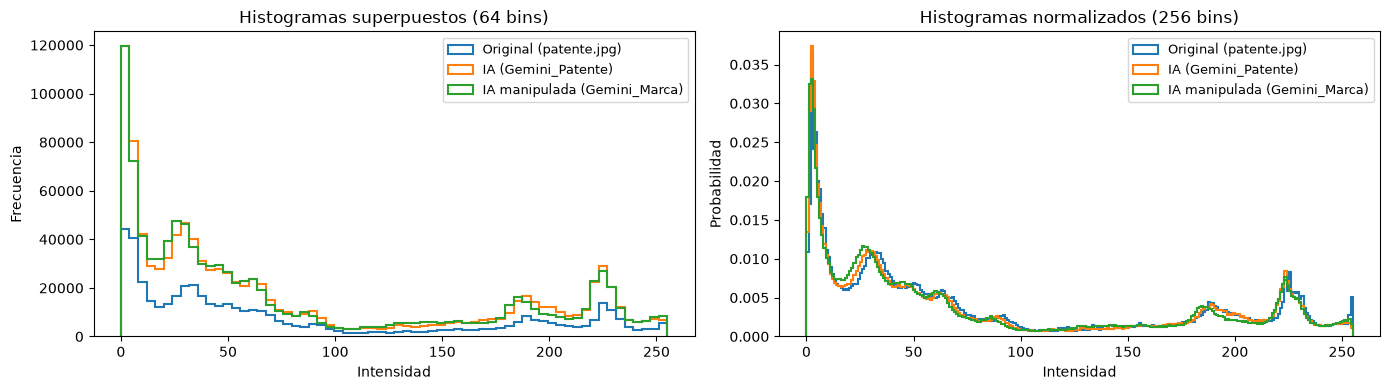

In [5]:
# --- 2.2 Histogramas: superpuestos y normalizados --------------------------------
fig, ejes = plt.subplots(1, 2, figsize=(14, 4))
for nombre, arr in imagenes.items():
    ejes[0].hist(arr.ravel(), bins=64, range=(0, 255), histtype="step",
                 linewidth=1.5, label=nombre)
ejes[0].set_title("Histogramas superpuestos (64 bins)")
ejes[0].set_xlabel("Intensidad")
ejes[0].set_ylabel("Frecuencia")
ejes[0].legend(fontsize=9)

for nombre, arr in imagenes.items():
    ejes[1].hist(arr.ravel(), bins=256, range=(0, 255), histtype="step",
                 density=True, linewidth=1.5, label=nombre)
ejes[1].set_title("Histogramas normalizados (256 bins)")
ejes[1].set_xlabel("Intensidad")
ejes[1].set_ylabel("Probabilidad")
ejes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

In [6]:
# --- 2.3 Percentiles y ocupación efectiva del rango --------------------------------
# Cuantifican cómo se reparte la masa de intensidades a lo largo del rango [0,255].
print(f"{'Imagen':<30} {'p1':>4} {'p25':>4} {'p50':>4} {'p75':>4} {'p99':>4} {'niveles(1..254)':>15}")
for nombre, arr in imagenes.items():
    p = np.percentile(arr, [1, 25, 50, 75, 99]).astype(int)
    hist, _ = np.histogram(arr, bins=256, range=(0, 256))
    usados = int(np.sum(hist[1:255] > 0))
    print(f"{nombre:<30} {p[0]:>4} {p[1]:>4} {p[2]:>4} {p[3]:>4} {p[4]:>4} {usados:>9} / 254")

Imagen                           p1  p25  p50  p75  p99 niveles(1..254)
Original (patente.jpg)            0   17   49  161  252       254 / 254
IA (Gemini_Patente)               0   15   46  160  249       254 / 254
IA manipulada (Gemini_Marca)      0   16   44  152  251       254 / 254


**Lectura en conjunto de los datos.**

Las tres imágenes son **oscuras**: promedio ≈ 80–83, **moda = 2** y **mediana ≈ 44–49**
(más de la mitad de los píxeles en la mitad baja del rango), con ≈ 40 % de los píxeles en
r ≤ 32. El rango técnico [0,255] está completo, pero la **masa está volcada hacia el
negro casi puro**: pobre aprovechamiento del rango. Esto define las necesidades de mejora:

1. **Brillo/contraste**: la masa concentrada en niveles bajos aprovecha mal el rango
   dinámico; hace falta redistribuirla (estiramiento percentil y ecualización de
   histograma) para revelar el detalle de la placa y de la marca.
2. **Procesamiento puntual**: el histograma muestra objetos claros (placa, marca, luces)
   sobre fondo oscuro; umbrales y realce de banda permiten segmentarlos y realzarlos.
3. **Ruido**: la compresión JPEG (bloques 8×8) y el re-encode de las derivadas inyectan
   ruido; se diagnostica con filtro de mediana y residuo.
4. **Bordes**: los cambios bruscos de intensidad (borde de la placa, contorno del
   vehículo, recuadro de la marca editada) se detectan con Sobel.

## 3. Etapa 3: Procesamiento de mejoras

Cada técnica está **justificada con los datos de la Etapa 2** y se **evidencia la mejora**
mediante métricas antes → después.

### 3.1 Brillo/contraste: estiramiento percentil y ecualización de histograma

- **Estiramiento percentil**: mapea el rango efectivo [percentil 2, percentil 98] al
  rango completo [0,255]; expande el contraste donde hay masa de píxeles.
- **Ecualización de histograma**: aplica la FDA (función de distribución acumulada)
  escalada como transformación puntual; redistribuye los niveles para uniformizar el
  histograma.

Ambas son **transformaciones puntuales** (cada píxel depende solo de su valor y de los
parámetros de la tabla de mapeo).

Evidencia: **redistribución de la masa de intensidades** — mediana y porcentaje de píxeles
en niveles bajos (r ≤ 32 y r ≤ 64) antes y después.

In [7]:
# --- 3.1.a Transformaciones de brillo/contraste (puntuales) ----------------------

def estirar_percentil(arr, pmin=2, pmax=98):
    """Estiramiento de contraste: mapea [pmin, pmax] (percentiles) a [0, L-1]."""
    L = niveles(arr.dtype)
    a, b = np.percentile(arr, [pmin, pmax])
    if b - a < 1:
        return np.array(arr)
    return np.clip((arr.astype(np.float64) - a) * ((L - 1) / (b - a)), 0, L - 1).astype(arr.dtype)


def ecualizar(arr):
    """Ecualización de histograma: transformación puntual basada en la FDA escalada."""
    L = niveles(arr.dtype)
    hist, _ = np.histogram(arr, bins=L, range=(0, L))
    cdf = hist.cumsum()
    cdf_min = cdf[cdf > 0].min()
    fda = (cdf - cdf_min) / (arr.size - cdf_min) * (L - 1)
    return fda[arr].astype(arr.dtype)

Imagen                         med ant  med ec %<=32 ant  %<=32 ec %<=64 ant  %<=64 ec
Original (patente.jpg)             49     127     37.7%     13.4%     59.2%     26.0%
IA (Gemini_Patente)                46     127     40.4%     13.7%     60.5%     26.1%
IA manipulada (Gemini_Marca)       44     125     41.3%     13.4%     61.6%     26.3%


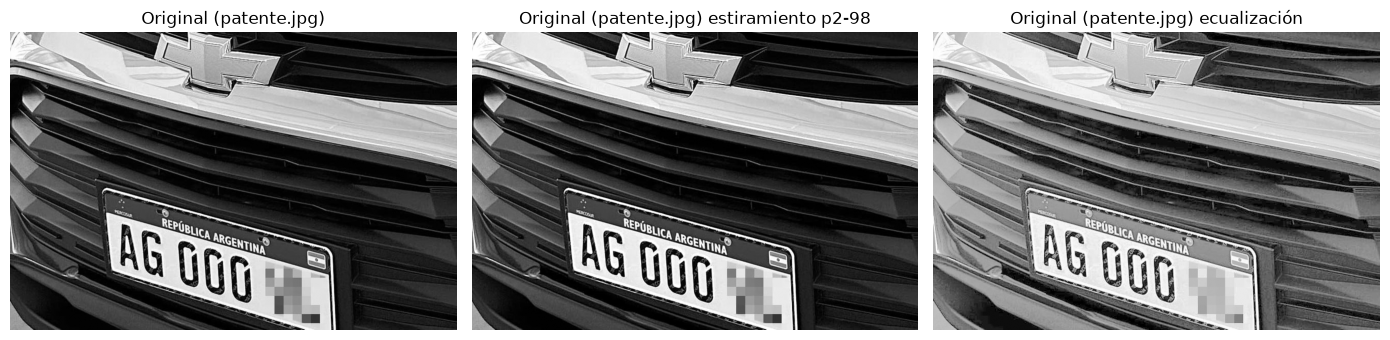

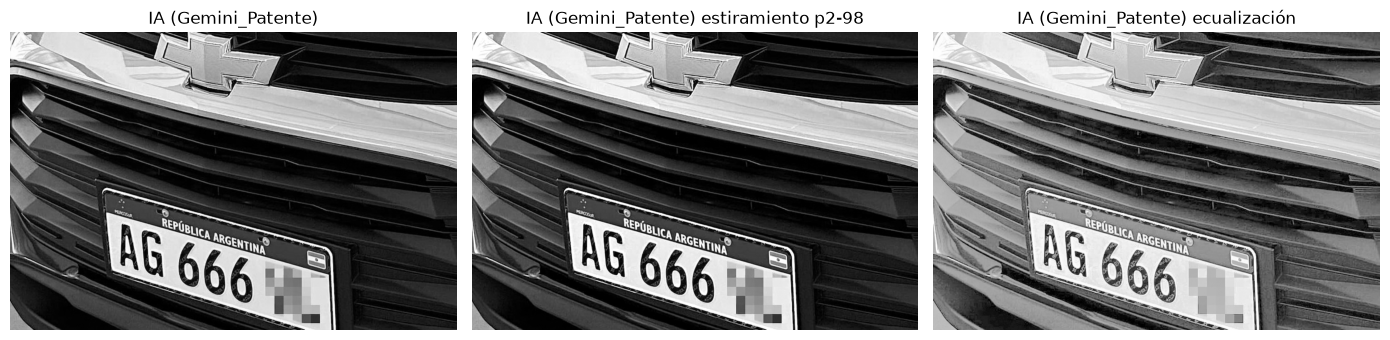

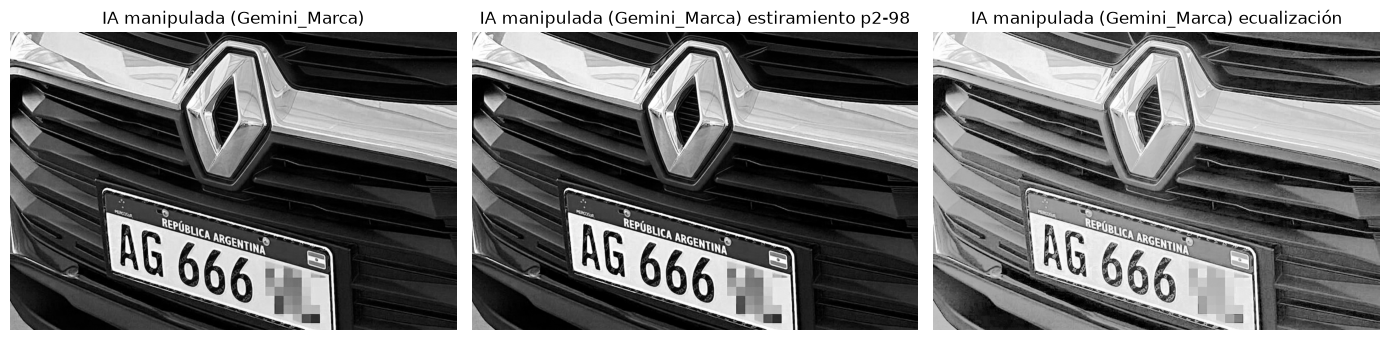

In [8]:
# --- 3.1.b Aplicación y evidencia ------------------------------------------------
def masa_baja(arr, umbral):
    """Porcentaje de píxeles por debajo o igual de un nivel umbral (masa oscura)."""
    return 100 * (arr <= umbral).mean()

mejoras = {}
for nombre, arr in imagenes.items():
    mejoras[nombre] = {"estirada": estirar_percentil(arr), "ecualizada": ecualizar(arr)}

print(f"{'Imagen':<30} {'med ant':>7} {'med ec':>7} {'%<=32 ant':>9} {'%<=32 ec':>9} "
      f"{'%<=64 ant':>9} {'%<=64 ec':>9}")
for nombre, arr in imagenes.items():
    e = mejoras[nombre]["ecualizada"]
    print(f"{nombre:<30} {np.median(arr):>6.0f} {np.median(e):>7.0f} "
          f"{masa_baja(arr, 32):>8.1f}% {masa_baja(e, 32):>8.1f}% "
          f"{masa_baja(arr, 64):>8.1f}% {masa_baja(e, 64):>8.1f}%")

# Comparación visual: original | estiramiento percentil | ecualización
for nombre, arr in imagenes.items():
    mostrar([arr, mejoras[nombre]["estirada"], mejoras[nombre]["ecualizada"]],
            titulos=[nombre, f"{nombre} estiramiento p2-98", f"{nombre} ecualización"],
            figsize=(14, 4))

**Resultado 3.1**: la ecualización **redistribuye la masa** hacia el centro del rango: la
mediana pasa de ≈ 44–49 a ≈ 127 y el porcentaje de píxeles en niveles bajos (r ≤ 32) cae
de ≈ 40 % a ≈ 14 %. El detalle de la placa y de la marca, antes oculto en el negro casi
puro, queda en la zona media del histograma y resulta visible. Mejora efectiva sobre el
histograma de la Etapa 2.

### 3.2 Procesamiento puntual: umbral y realce de banda

Del histograma surge una separación **fondo oscuro vs. objeto claro** (placa/marca/luces).
Se aplican dos operadores puntuales del TP2 con los parámetros fijos $[a, b]$:

- **Intervalo umbral binario**: 255 si $a \leq r \leq b$, 0 en el resto → segmenta la ROI.
- **Realce de banda de interés**: estira la banda $[a, b]$ al rango completo y apaga el
  resto → amplifica el contraste interno de la región de interés.

Evidencia: porcentaje de píxeles que pertenecen a la banda en cada imagen.

Píxeles en la banda [150, 230]:
  Original (patente.jpg): 21.0%
  IA (Gemini_Patente): 21.7%
  IA manipulada (Gemini_Marca): 20.4%


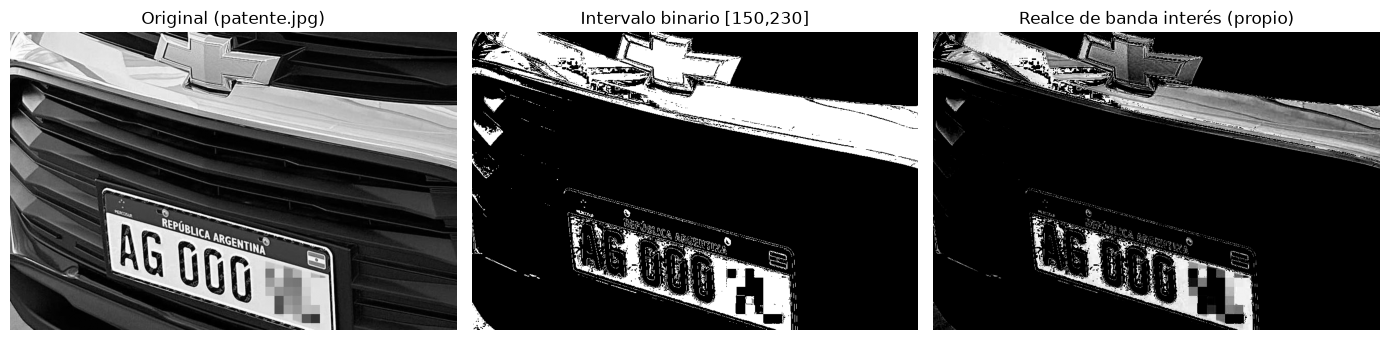

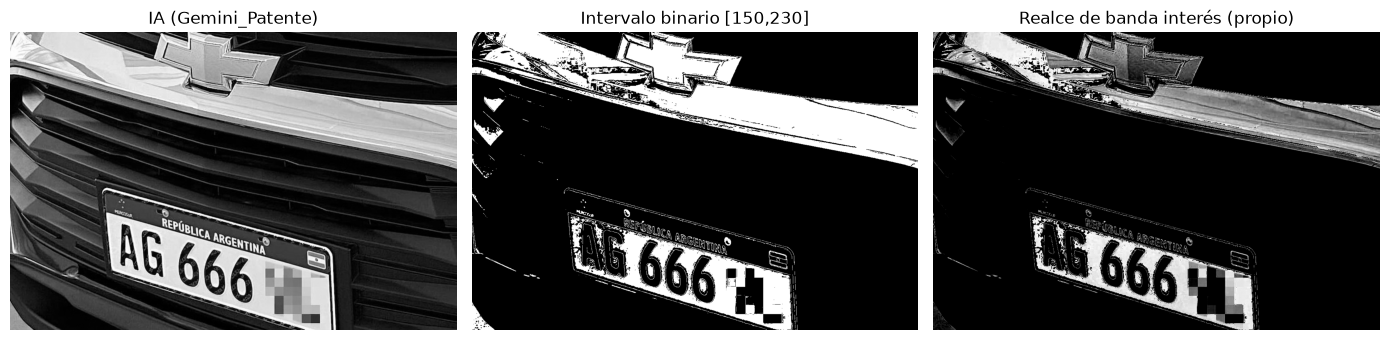

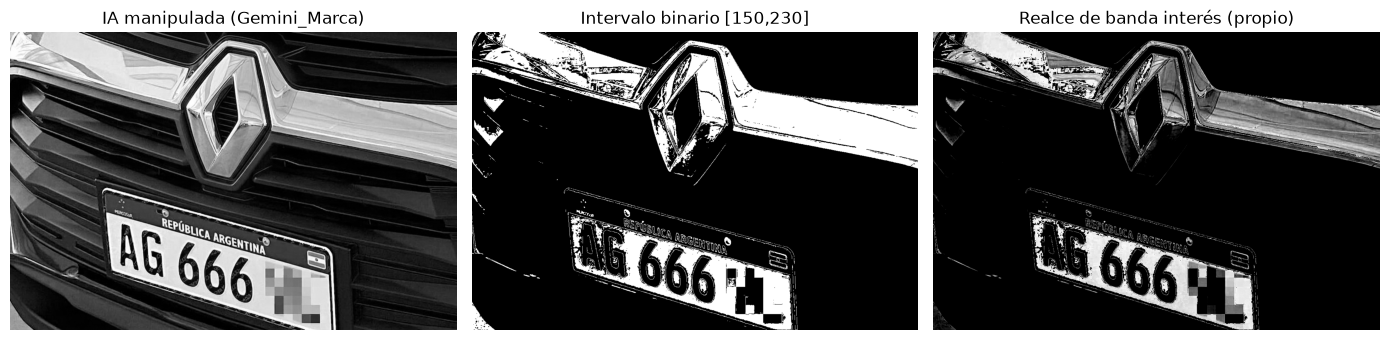

In [9]:
# --- 3.2.a Operadores puntuales (TP2) ---------------------------------------------
a_banda, b_banda = 150, 230   # banda de los objetos claros (el fondo es oscuro: moda=2)

def umbral_intervalo_binario(arr, a, b):
    """Intervalo umbral binario: 255 si a <= r <= b, 0 en el resto."""
    maximo = niveles(arr.dtype) - 1
    return np.where((arr >= a) & (arr <= b), maximo, 0).astype(arr.dtype)


def realce_banda_interes(arr, a, b, fondo=0):
    """Estira el contraste dentro de [a, b] al rango completo y apaga el resto."""
    maximo = niveles(arr.dtype) - 1
    rango = b - a
    if rango <= 0:
        return np.array(arr)
    banda = np.clip((arr.astype(np.float64) - a) * (maximo / rango), 0, maximo).astype(arr.dtype)
    return np.where((arr >= a) & (arr <= b), banda, fondo).astype(arr.dtype)


# Máscaras binarias y versiones realzadas de la banda de objetos claros
binarias = {nombre: umbral_intervalo_binario(arr, a_banda, b_banda)
            for nombre, arr in imagenes.items()}
realces = {nombre: realce_banda_interes(arr, a_banda, b_banda)
           for nombre, arr in imagenes.items()}

print(f"Píxeles en la banda [{a_banda}, {b_banda}]:")
for nombre, b in binarias.items():
    print(f"  {nombre}: {100 * (b > 0).mean():.1f}%")

# Comparación visual por imagen: original | umbral binario | realce de banda
for nombre in imagenes:
    mostrar([imagenes[nombre], binarias[nombre], realces[nombre]],
            titulos=[nombre, f"Intervalo binario [{a_banda},{b_banda}]",
                     "Realce de banda interés (propio)"],
            figsize=(14, 4))

### 3.3 Ruido: filtro de mediana y diagnóstico por residuo

La compresión JPEG y el re-encode de las derivadas agregan ruido. El **filtro de mediana**
3×3 reemplaza cada píxel por la mediana de su vecindad, eliminando picos impulsivos y
granularidad sin difuminar bordes como un promedio.

Evidencia: en una **región homogénea** (esquina superior derecha) el desvío estándar debe
bajar después del filtrado (ruido suavizado) y el **residuo** |original − mediana| queda
como mapa del ruido removido; se reporta además el **PSNR** entre original y filtrada.

Original (patente.jpg)
  std región plana: 19.3 -> 18.3 (5.2% menos ruido)
  PSNR(original, mediana): 32.1 dB
IA (Gemini_Patente)
  std región plana: 15.1 -> 14.8 (1.5% menos ruido)
  PSNR(original, mediana): 37.5 dB
IA manipulada (Gemini_Marca)
  std región plana: 14.6 -> 14.3 (1.6% menos ruido)
  PSNR(original, mediana): 37.6 dB


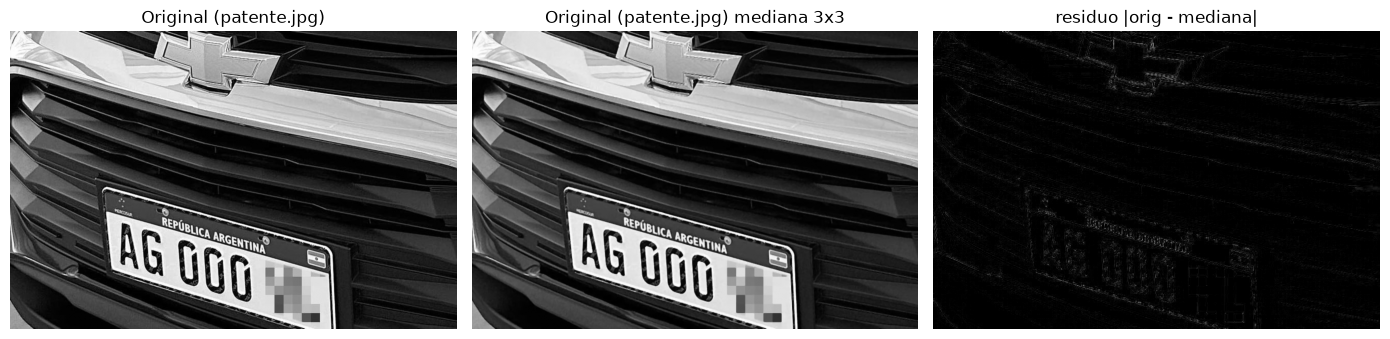

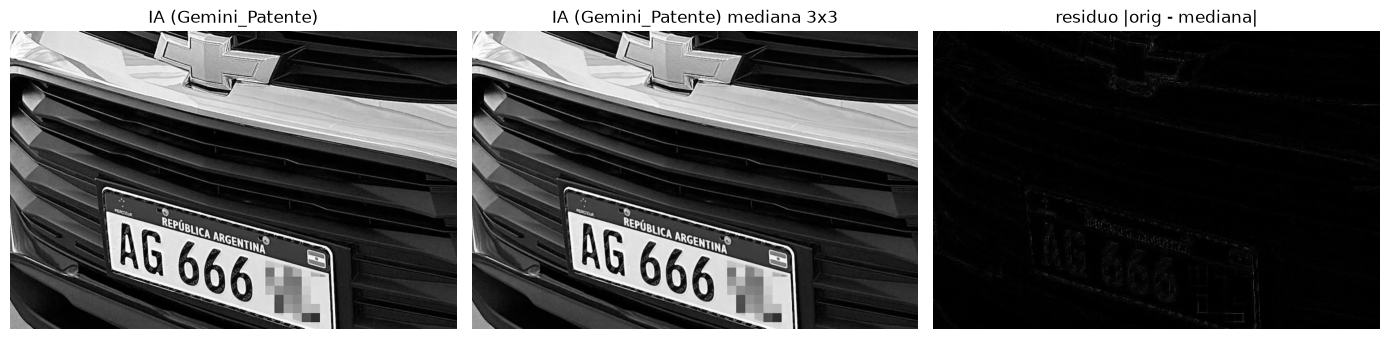

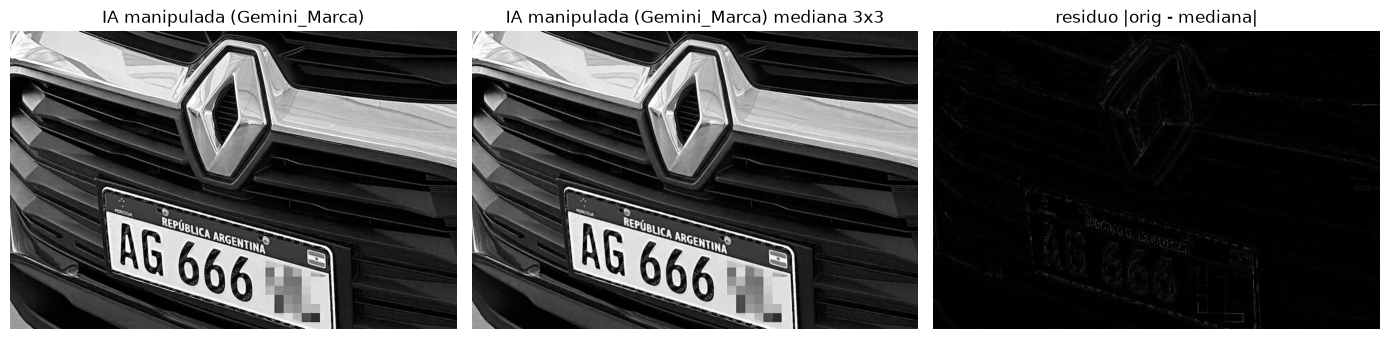

In [10]:
# --- 3.3.a Filtro de mediana, residuo y métricas --------------------------------
def mediana(arr, radio=1):
    """Filtro de mediana con ventana cuadrada (2*radio+1)^2 vía PIL ImageFilter."""
    return np.asarray(Image.fromarray(arr).filter(ImageFilter.MedianFilter(2 * radio + 1)))


def psnr(a, b):
    """Relación señal a ruido de pico (dB) entre dos imágenes uint8."""
    mse = np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2)
    return float("inf") if mse == 0 else 10 * np.log10(255.0 ** 2 / mse)


def region_plana(arr):
    """Región candidata homogénea: los primeros 120 filas a la derecha."""
    _, w = arr.shape
    return (slice(0, 120), slice(max(0, w - 300), w))


filtradas = {}
for nombre, arr in imagenes.items():
    filtradas[nombre] = mediana(arr)
    r = region_plana(arr)
    antes, despues = arr[r].std(), filtradas[nombre][r].std()
    print(f"{nombre}")
    print(f"  std región plana: {antes:.1f} -> {despues:.1f} "
          f"({100 * (1 - despues / max(antes, 1e-9)):.1f}% menos ruido)")
    print(f"  PSNR(original, mediana): {psnr(arr, filtradas[nombre]):.1f} dB")

for nombre, arr in imagenes.items():
    residuo = np.abs(arr.astype(np.int16) - filtradas[nombre].astype(np.int16)).astype(np.uint8)
    mostrar([arr, filtradas[nombre], residuo],
            titulos=[nombre, f"{nombre} mediana 3x3", "residuo |orig - mediana|"],
            figsize=(14, 4))

### 3.4 Detección de bordes: gradiente de Sobel

La **magnitud del gradiente de Sobel** indica los cambios bruscos de intensidad: bordes de
la placa, contorno del vehículo y recuadro de la marca editada. Se implementa con
convoluciones discretas 3×3 (numpy, sin scipy) y se umbraliza en el percentil 90 para
binarizar los bordes dominantes.

Original (patente.jpg): gradiente medio 76.8 | umbral de bordes p90 196
IA (Gemini_Patente): gradiente medio 60.2 | umbral de bordes p90 149
IA manipulada (Gemini_Marca): gradiente medio 62.4 | umbral de bordes p90 154


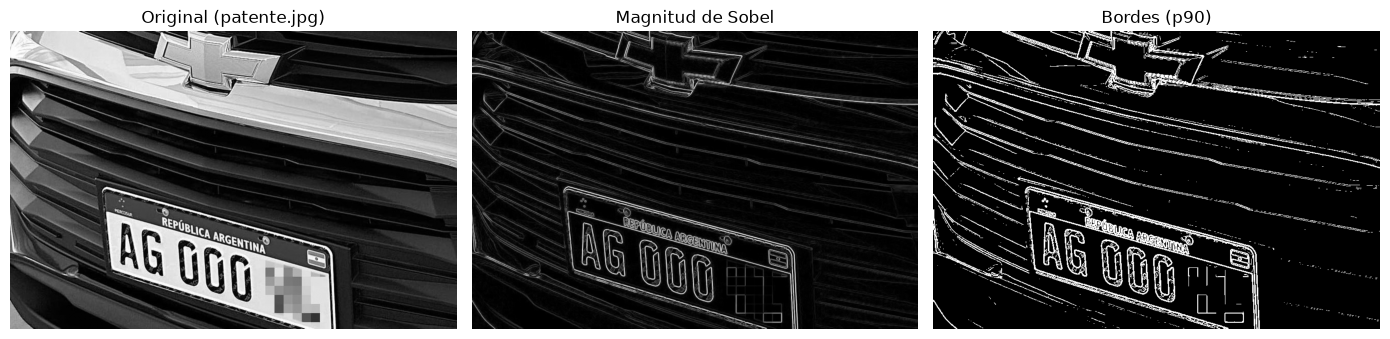

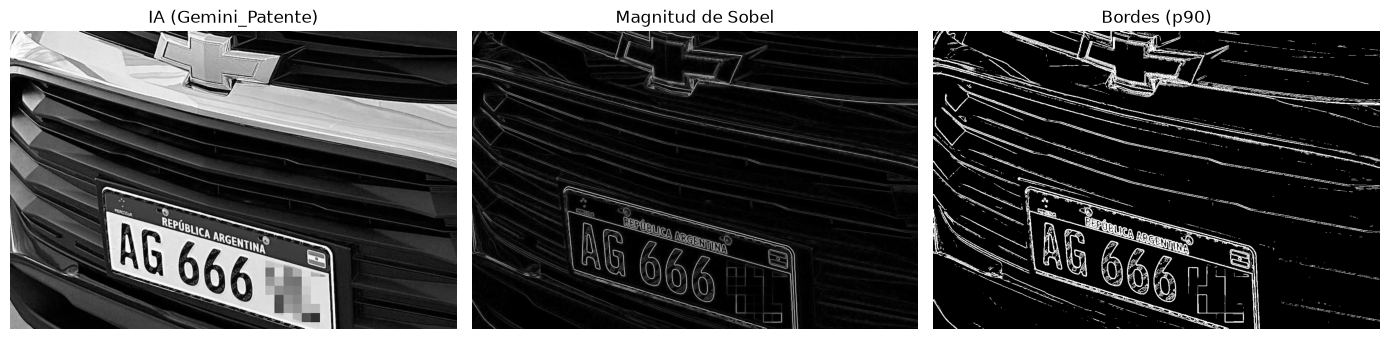

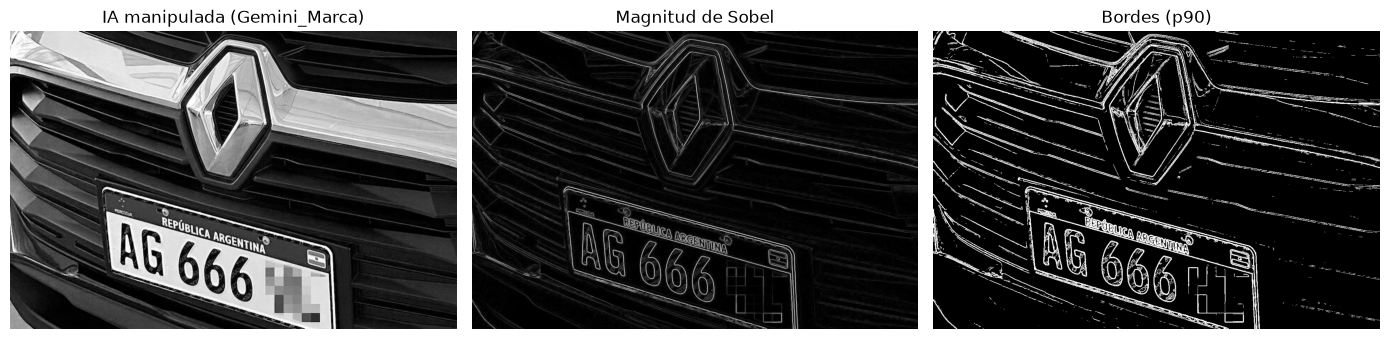

In [11]:
# --- 3.4.a Gradiente de Sobel con numpy ----------------------------------------
def convolucion3x3(a, k):
    """Convolución 2D con kernel 3x3 (borde por replicación), vectorizada."""
    a_pad = np.pad(a, 1, mode="edge").astype(np.float64)
    salida = np.zeros_like(a, dtype=np.float64)
    for di in range(3):
        for dj in range(3):
            salida += k[di, dj] * a_pad[di:di + a.shape[0], dj:dj + a.shape[1]]
    return salida


def sobel(arr):
    """Magnitud del gradiente de Sobel: sqrt(Gx^2 + Gy^2)."""
    kx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float64)
    ky = kx.T
    gx = convolucion3x3(arr, kx)
    gy = convolucion3x3(arr, ky)
    return np.sqrt(gx ** 2 + gy ** 2)


bordes = {}
for nombre, arr in imagenes.items():
    g = sobel(arr)
    t = np.percentile(g, 90)                       # umbral p90: bordes dominantes
    bordes[nombre] = (g > t).astype(np.uint8) * 255
    print(f"{nombre}: gradiente medio {g.mean():.1f} | umbral de bordes p90 {t:.0f}")

for nombre, arr in imagenes.items():
    g = sobel(arr)
    gm = (g / max(g.max(), 1e-9) * 255).astype(np.uint8)
    mostrar([arr, gm, bordes[nombre]],
            titulos=[nombre, "Magnitud de Sobel", "Bordes (p90)"],
            figsize=(14, 4))

### 3.5 Detección de la manipulación: sustracción punto a punto

Como **final corolario** del proyecto, se localiza la edición:

- **(a)** Entre las dos derivadas IA (misma escena, mismo tamaño), la **sustracción**
  punto a punto aísla la *edición local*: la zona de la marca modificada queda como un
  hotspot de gran diferencia.
- **(b)** Entre la **imagen original** (patente.jpg, reescalada) y la derivada manipulada
  la diferencia es global: la derivada difiere del original real en toda la escena (la
  "huella" IA se evidencia en los píxeles).

Diferencia media |IA original - IA manipulada|: 11.85
Zona de edición (marca): x[376..823] y[0..472] | 5.87% de píxeles
Diferencia media |Original real - IA manipulada|: 15.28


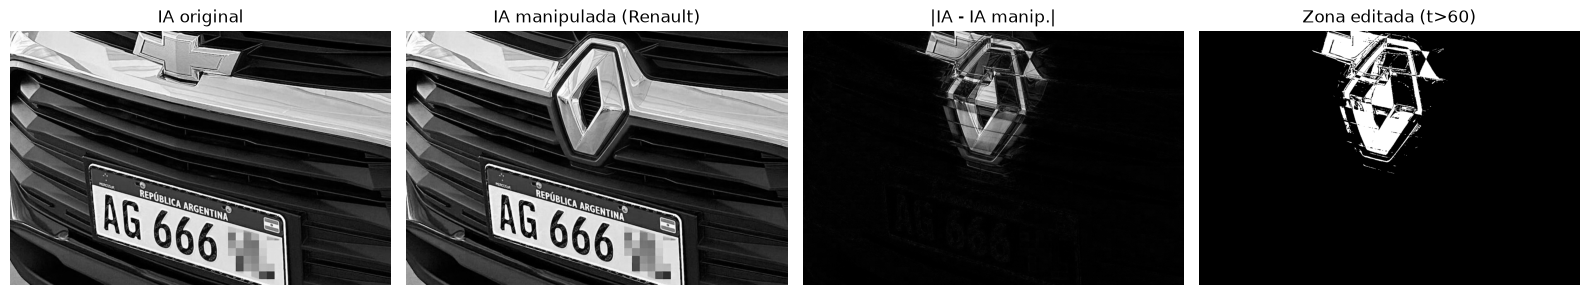

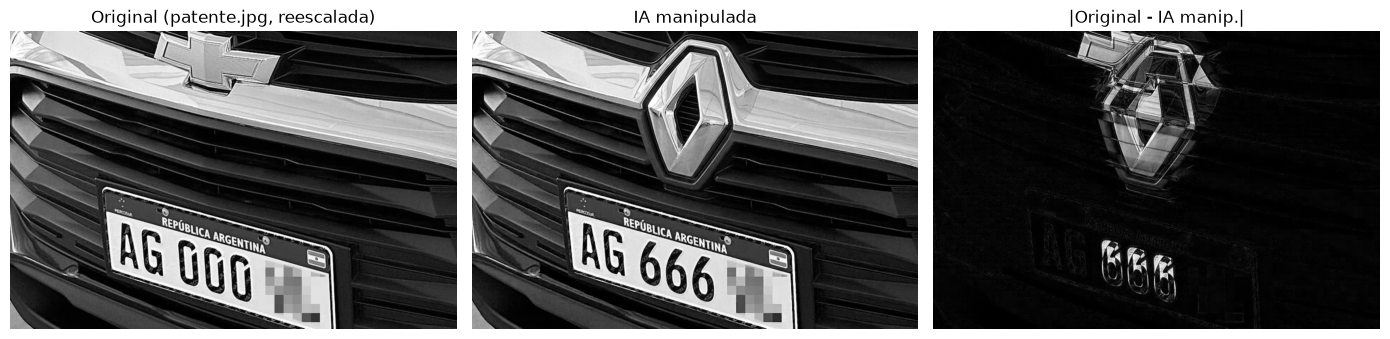

In [12]:
# --- 3.5.a Sustracción y localización de la edición ------------------------------
def sustraccion(a, b):
    """Diferencia absoluta punto a punto entre dos imágenes del mismo tamaño."""
    return np.abs(a.astype(np.int32) - b.astype(np.int32)).astype(np.uint8)


# (a) Entre las dos derivadas IA: aísla la edición local (cambio de marca).
diff_ia = sustraccion(imagenes["IA (Gemini_Patente)"],
                      imagenes["IA manipulada (Gemini_Marca)"])
print("Diferencia media |IA original - IA manipulada|:", round(float(diff_ia.mean()), 2))

hotspot = diff_ia > 60                              # solo los cambios fuertes
ys, xs = np.where(hotspot)
if hotspot.sum() > 0:
    print("Zona de edición (marca):",
          f"x[{xs.min()}..{xs.max()}] y[{ys.min()}..{ys.max()}]",
          f"| {100 * hotspot.mean():.2f}% de píxeles")

# (b) Original real vs. derivada manipulada (reescalada al mismo tamaño).
original_redim = np.asarray(
    Image.fromarray(imagenes["Original (patente.jpg)"]).resize((1264, 843), Image.LANCZOS)
).astype(np.uint8)
diff_orig = sustraccion(original_redim, imagenes["IA manipulada (Gemini_Marca)"])
print("Diferencia media |Original real - IA manipulada|:", round(float(diff_orig.mean()), 2))

mostrar([imagenes["IA (Gemini_Patente)"], imagenes["IA manipulada (Gemini_Marca)"],
         diff_ia, (hotspot * 255).astype(np.uint8)],
        titulos=["IA original", "IA manipulada (Renault)", "|IA - IA manip.|",
                 "Zona editada (t>60)"],
        figsize=(16, 4))
mostrar([original_redim, imagenes["IA manipulada (Gemini_Marca)"], diff_orig],
        titulos=["Original (patente.jpg, reescalada)", "IA manipulada",
                 "|Original - IA manip.|"],
        figsize=(14, 4))

## 4. Resumen de mejoras aplicadas y evidencia

La tabla siguiente se genera con los valores medidos durante el procesamiento.

In [13]:
# --- 4.1 Tabla resumen de mejora por técnica e imagen ----------------------------
print("| Imagen | Técnica | Antes | Después | Evidencia |")
print("|---|---|---|---|---|")
for nombre, arr in imagenes.items():
    e = mejoras[nombre]["ecualizada"]
    m = filtradas[nombre]
    print(f"| {nombre} | Contraste (ecualización) | mediana {np.median(arr):.0f}, "
          f"{masa_baja(arr, 32):.0f}% en r<=32 | mediana {np.median(e):.0f}, "
          f"{masa_baja(e, 32):.0f}% en r<=32 | masa redistribuida, detalle visible |")
    r = region_plana(arr)
    print(f"| {nombre} | Ruido (mediana 3x3) | std región plana {arr[r].std():.1f} | "
          f"std {m[r].std():.1f} | {psnr(arr, m):.1f} dB, residuo ~{np.abs(arr.astype(np.int16) - m.astype(np.int16))[r].mean():.1f} |")
    g = sobel(arr)
    print(f"| {nombre} | Bordes (Sobel) | gradiente medio {g.mean():.1f} | umbral p90 "
          f"{np.percentile(g, 90):.0f} | bordes de placa/marca delimitados |")

print()
print("Resultado de detección:")
print(f"- Edición local (marca) entre las dos IA: "
      f"{100 * hotspot.mean():.3f}% de píxeles con |diff|>60.")
print(f"- Distancia del original real a la derivada manipulada: "
      f"diferencia media {diff_orig.mean():.1f} sobre 255.")

| Imagen | Técnica | Antes | Después | Evidencia |
|---|---|---|---|---|
| Original (patente.jpg) | Contraste (ecualización) | mediana 49, 38% en r<=32 | mediana 127, 13% en r<=32 | masa redistribuida, detalle visible |
| Original (patente.jpg) | Ruido (mediana 3x3) | std región plana 19.3 | std 18.3 | 32.1 dB, residuo ~1.2 |
| Original (patente.jpg) | Bordes (Sobel) | gradiente medio 76.8 | umbral p90 196 | bordes de placa/marca delimitados |
| IA (Gemini_Patente) | Contraste (ecualización) | mediana 46, 40% en r<=32 | mediana 127, 14% en r<=32 | masa redistribuida, detalle visible |
| IA (Gemini_Patente) | Ruido (mediana 3x3) | std región plana 15.1 | std 14.8 | 37.5 dB, residuo ~0.6 |
| IA (Gemini_Patente) | Bordes (Sobel) | gradiente medio 60.2 | umbral p90 149 | bordes de placa/marca delimitados |
| IA manipulada (Gemini_Marca) | Contraste (ecualización) | mediana 44, 41% en r<=32 | mediana 125, 13% en r<=32 | masa redistribuida, detalle visible |
| IA manipulada (Gemini_Marca) | 